<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [43]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 151.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


### Step 1: Import Required Libraries


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [3]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [10]:
## Write your code here

print(df.duplicated().sum())

#check for actual duplicate response IDs
#print(df["ResponseId"].duplicated().sum())

#identify repeated Response IDs
print(df[df.duplicated(subset=["ResponseId"], keep=False)])

10
       ResponseId                                         MainBranch  \
0               1                     I am a developer by profession   
1               2                     I am a developer by profession   
2               3                     I am a developer by profession   
3               4                              I am learning to code   
4               5                     I am a developer by profession   
5               6                        I code primarily as a hobby   
6               7  I am not primarily a developer, but I write co...   
7               8                              I am learning to code   
8               9                        I code primarily as a hobby   
9              10                     I am a developer by profession   
65437           1                     I am a developer by profession   
65438           2                     I am a developer by profession   
65439           3                     I am a developer by pro

##### Task 2: Remove the duplicate rows from the dataframe.



In [12]:
## Write your code here

df_clean = df.copy()

#ensuring the the copied df is providing the same information
#print(df_clean["ResponseId"].duplicated().sum())
#print(df_clean[df.duplicated(subset=["ResponseId"], keep=False)])

#delete those duplicate rows
df_clean = df_clean.drop_duplicates(subset=["ResponseId"])

#compare the number of rows
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))

#verify that no duplicates remain in the copied df
print(df_clean["ResponseId"].duplicated().sum())

Original rows: 65447
Clean rows: 65437
0

### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [13]:
## Write your code here

#Displays all the columns
pd.set_option("display.max_rows", None)

#counts missing values in each column and sort them 
print(df_clean.isnull().sum().sort_values(ascending=False))

AINextMuch less integrated        64289
AINextLess integrated             63082
AINextNo change                   52939
AINextMuch more integrated        51999
EmbeddedAdmired                   48704
EmbeddedWantToWorkWith            47837
EmbeddedHaveWorkedWith            43223
ConvertedCompYearly               42002
AIToolNot interested in Using     41023
AINextMore integrated             41009
Knowledge_9                       37802
Frequency_3                       37727
Knowledge_8                       37679
ProfessionalTech                  37673
Knowledge_7                       37659
Knowledge_6                       37573
Knowledge_5                       37557
Knowledge_2                       37416
Knowledge_4                       37407
Knowledge_3                       37342
Frustration                       37186
Frequency_2                       37073
Frequency_1                       37068
ProfessionalCloud                 36946
Knowledge_1                       36773


##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [17]:
## Write your code here
#Find the number of missing rows in RemoteWork column

print("There are", df_clean["RemoteWork"].isnull().sum(), "missing values in the RemoteWork column")



There are 10631 missing values in the RemoteWork column

### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [18]:
## Write your code here

# Counts how many times each unique value appears in the RemoteWork column
df_clean["RemoteWork"].value_counts()

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [19]:
## Write your code here

#Find the most frequent value in RemoteWork 

Most_RemoteWork = df_clean["RemoteWork"].mode()[0]
print("Most frequent RemoteWork is", Most_RemoteWork)


Most frequent RemoteWork is Hybrid (some remote, some in-person)

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [21]:
## Write your code here

#Impute with the most frequent RemoteWork

df_clean["RemoteWork"] = df_clean["RemoteWork"].fillna(Most_RemoteWork)
print(df_clean["RemoteWork"].head())

#Confirms that there are now NO missing rows for this column

print("There are", df_clean["RemoteWork"].isnull().sum(), "missing values in the RemoteWork column")



0                                  Remote
1                                  Remote
2                                  Remote
3    Hybrid (some remote, some in-person)
4    Hybrid (some remote, some in-person)
Name: RemoteWork, dtype: str
There are 0 missing values in the RemoteWork column

##### Task 8: Check for any compensation-related columns and describe their distribution.



There are 0 missing values in the ConvertedCompYearly column
There are 0 missing values in the CompTotal column
Most frequent ConvertedCompYearly is 64444.0
Most frequent CompTotal is 100000.0
Now there are 0 missing values in the ConvertedCompYearly column
Now there are 0 missing values in the CompTotal column
       ConvertedCompYearly      CompTotal
count         6.543700e+04   6.543700e+04
mean          7.221948e+04  1.528187e+145
std           1.122451e+05  3.909204e+147
min           1.000000e+00   0.000000e+00
25%           6.444400e+04   1.000000e+05
50%           6.444400e+04   1.000000e+05
75%           6.444400e+04   1.140000e+05
max           1.625660e+07  1.000000e+150

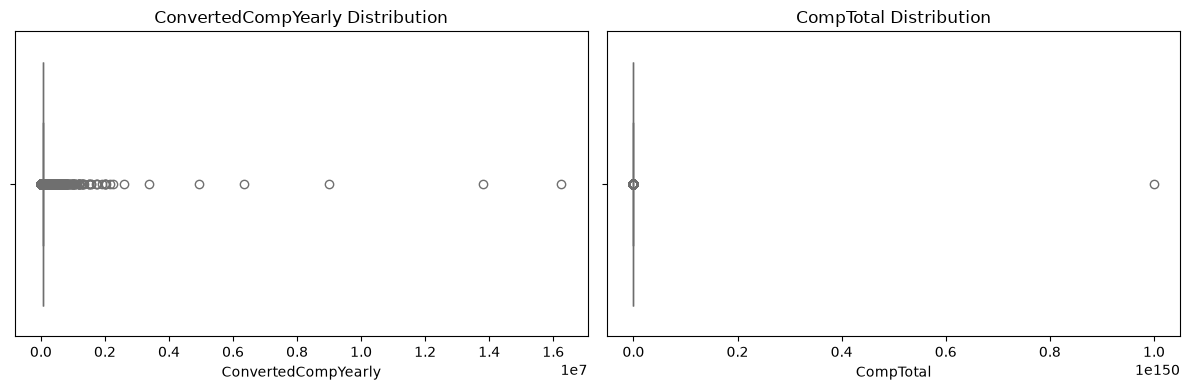

In [59]:
## Write your code here

#These are the compensation related columns ConvertedCompYearly, CompTotal

#first check for missing values
print("There are", df_clean["ConvertedCompYearly"].isnull().sum(), "missing values in the ConvertedCompYearly column")
print("There are", df_clean["CompTotal"].isnull().sum(), "missing values in the CompTotal column")

#Check for the most frequent values
Most_ConvertedCompYearly = df_clean["ConvertedCompYearly"].mode()[0]
print("Most frequent ConvertedCompYearly is", Most_ConvertedCompYearly)

Most_CompTotal = df_clean["CompTotal"].mode()[0]
print("Most frequent CompTotal is", Most_CompTotal)

#Replace missing values with the most frequent values 
df_clean["ConvertedCompYearly"] = df_clean["ConvertedCompYearly"].fillna(Most_ConvertedCompYearly)
df_clean["CompTotal"] = df_clean["CompTotal"].fillna(Most_CompTotal)

#Confirm that there are NO missing values anymore
print("Now there are", df_clean["ConvertedCompYearly"].isnull().sum(), "missing values in the ConvertedCompYearly column")
print("Now there are", df_clean["CompTotal"].isnull().sum(), "missing values in the CompTotal column")

#Now that the columns have been cleaned of missing values and normalized, we can check to see the distributions
Pay_summary = df_clean[["ConvertedCompYearly", "CompTotal"]].describe()
print(Pay_summary)

#Visualize both columns

#df_clean["ConvertedCompYearly"].plot(kind='hist', bins=5)
#df_clean[ "CompTotal"].plot(kind='hist', bins=5)

#sns.boxplot(x=df_clean[['ConvertedCompYearly','CompTotal']])
#plt.title("ConvertedCompYearly Distribution with Outliers")
#plt.show()

# Create a figure with 1 row and 2 columns of plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the first column on the first axis (axes[0])
sns.boxplot(x=df_clean['ConvertedCompYearly'], ax=axes[0], color='skyblue')
axes[0].set_title("ConvertedCompYearly Distribution")

# Plot the second column on the second axis (axes[1])
sns.boxplot(x=df_clean['CompTotal'], ax=axes[1], color='salmon')
axes[1].set_title("CompTotal Distribution")

plt.tight_layout() # Prevents titles and labels from overlapping
plt.show()


### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
